In [3]:
# ============================================================
# Cell 0 - Import Packages and Load BTMS Model
# ============================================================

import os
import sys
import io
import re
import contextlib
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import CoolProp.CoolProp as CP

PROJECT_ROOT = os.path.abspath("../..")

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import lib.BTMS_model as BTMS_model

# Always reload the latest BTMS_model.py.
BTMS_model = importlib.reload(BTMS_model)

print(f'Project root: {PROJECT_ROOT}')
print(f'BTMS_model loaded from: {BTMS_model.__file__}')


Project root: d:\eBATS
BTMS_model loaded from: d:\eBATS\lib\BTMS_model.py


In [4]:
# ============================================================
# Cell 1 - Result-File Naming Configuration
# ============================================================

# [RESULTID]_[SCN]_[BTMS]_[MODEL]_[TASK].[ext]
# This notebook evaluates the final LC-PARK design selected from C0003R03.

CASE_ID = 'C0009'
REVISION = 'R01'
RESULT_ID = f'{CASE_ID}{REVISION}'

SCENARIO_CODE = 'PARK25'
BTMS_CODE = 'LC'
MODEL_CODE = '1D'
TASK_CODE = 'EVAL'

RESULT_BASENAME = f'{RESULT_ID}_{SCENARIO_CODE}_{BTMS_CODE}_{MODEL_CODE}_{TASK_CODE}'
NOTEBOOK_NAME = f'{RESULT_BASENAME}.ipynb'
OUTPUT_DIR = os.path.join(PROJECT_ROOT, 'out', CASE_ID)
os.makedirs(OUTPUT_DIR, exist_ok=True)

RESULT_FIGURE_NAME = f'{RESULT_BASENAME}_CFD_COMPARE.png'

# CFD comparison data for C0009.
# Put the following Fluent report files in:
#   data/C0009/max-rfile.out
#   data/C0009/min-rfile.out
ENABLE_CFD_COMPARISON = True

CFD_DATA_DIR = os.path.join(
    PROJECT_ROOT,
    'data',
    CASE_ID,
)

CFD_FILES = {
    'CFD_max': 'max-rfile.out',
    'CFD_min': 'min-rfile.out',
}

print(f'Result basename: {RESULT_BASENAME}')
print(f'Notebook file: {NOTEBOOK_NAME}')
print(f'CFD data directory: {CFD_DATA_DIR}')
print(f'CFD comparison enabled: {ENABLE_CFD_COMPARISON}')


Result basename: C0009R01_PARK25_LC_1D_EVAL
Notebook file: C0009R01_PARK25_LC_1D_EVAL.ipynb
CFD data directory: d:\eBATS\data\C0009
CFD comparison enabled: True


In [5]:
# ============================================================
# Cell 2 - Load Battery Heat-Generation Data
# ============================================================

SIM_DURATION_S = 1920.0   # s, physical mission duration
dt = 1.0                  # s, integration time step

NUM_STEPS = int(round(SIM_DURATION_S / dt))
if not np.isclose(NUM_STEPS * dt, SIM_DURATION_S):
    raise ValueError('SIM_DURATION_S must be an integer multiple of dt.')

# Keep the original downstream variable name.
SIM_TIME_S = NUM_STEPS

file_name = os.path.join(
    PROJECT_ROOT,
    'data',
    'MD05E070207A1  data_power gen_single cell_Liu_20260421.xlsx',
)

if not os.path.isfile(file_name):
    raise FileNotFoundError(
        f'Heat-generation data file not found: {file_name}\n'
        'Place the Excel file in the project data folder.'
    )

df = pd.read_excel(file_name, sheet_name='Sheet1')
power_generation_data_1s = df['Qbat(W)'].dropna().to_numpy(dtype=float)

# Source Qbat data are 1-s samples.
time_s = np.arange(SIM_TIME_S + 1) * dt
power_indices = np.floor(time_s[:-1]).astype(int)
power_indices = np.clip(power_indices, 0, len(power_generation_data_1s) - 1)
power_generation_data = power_generation_data_1s[power_indices]

print(f'Simulation duration: {SIM_DURATION_S:.1f} s')
print(f'Time step dt: {dt:.3f} s')
print(f'Number of numerical steps: {SIM_TIME_S}')
print(f'Q_gen array length: {len(power_generation_data)}')


Simulation duration: 1920.0 s
Time step dt: 1.000 s
Number of numerical steps: 1920
Q_gen array length: 1920


In [6]:
# ============================================================
# Cell 3 - Model Settings and LC-PARK Evaluation Conditions
# ============================================================

BATTERY_PROPS = {
    'm_bat': 48e-3,          # kg
    'cp_bat': 830.0,         # J/(kg K)
    'D_bat': 18e-3,          # m
    'H_bat': 65e-3,          # m
}

MODULE_LAYOUT = {
    'N_r': 20,               # control volumes along coolant-flow direction
    'N_c': 16,               # battery columns in transverse direction
}

LIQUID_SETTINGS = {
    'fluid': 'Water',
    'p_water': 101325.0,
    'W_channel': 10.0e-3,
    'H_channel': 3.0e-3,
    'L_channel': 0.380,
    'W_battery': 16 * 18.0e-3,
    'S_min': 1.0e-3,
    'delta_plate_coolant': 2.0e-3,
    'k_plate': 200.0,
    'rho_plate': 2719.0,
    'pump_efficiency': 0.35,
    'K_minor': 0.0,
    'm_pump': 0.0,
    'm_pipe': 0.0,
}

# Final design selected from C0003R03.
SELECTED_CONDITION = {
    'case_id': f'{CASE_ID}_S001',
    'T_water': 25.0,
    'm_dot_total': 0.045,
    'num_parallel_channels': 32,
    'W_channel_case': 10.0e-3,
    'H_channel_case': 3.0e-3,
    'L_channel_case': 0.380,
    'S_channel_fixed': None,
}

# Baseline design from C0002R01_PARK25_LC_1D_VAL.
# The C0002 operating/geometry parameters are evaluated here with the latest C0009 calculation logic.
BASELINE_CONDITION = {
    'case_id': f'{RESULT_ID}_BASELINE',
    'T_water': 25.0,
    'm_dot_total': 0.06106836,
    'num_parallel_channels': 20,
    'W_channel_case': 8.0e-3,
    'H_channel_case': 3.0e-3,
    'L_channel_case': 0.380,
    'S_channel_fixed': 17.77e-3,
}

SOLVER_SETTINGS = {
    'solver_tol': 1e-6,
    'solver_maxiter': 1000,
}

mission_stages = [
    ('takeoff',       0.0,    6.0),
    ('climb',         6.0,   36.0),
    ('transition1',  36.0,  180.0),
    ('cruise',      180.0, 1560.0),
    ('transition2',1560.0, 1704.0),
    ('descent',    1704.0, 1734.0),
    ('hover',      1734.0, 1914.0),
    ('landing',    1914.0, 1920.0),
]

m_bat = BATTERY_PROPS['m_bat']
cp_bat = BATTERY_PROPS['cp_bat']
D_bat = BATTERY_PROPS['D_bat']
H_bat = BATTERY_PROPS['H_bat']
A_battery = np.pi * D_bat * H_bat
N_r = MODULE_LAYOUT['N_r']
N_c = MODULE_LAYOUT['N_c']
num_seg = N_r
fluid = LIQUID_SETTINGS['fluid']
p_water = LIQUID_SETTINGS['p_water']
W_channel = LIQUID_SETTINGS['W_channel']
H_channel = LIQUID_SETTINGS['H_channel']
L_channel = LIQUID_SETTINGS['L_channel']
W_battery = LIQUID_SETTINGS['W_battery']
S_min = LIQUID_SETTINGS['S_min']
delta_plate_coolant = LIQUID_SETTINGS['delta_plate_coolant']
k_plate = LIQUID_SETTINGS['k_plate']
rho_plate = LIQUID_SETTINGS['rho_plate']
pump_efficiency = LIQUID_SETTINGS['pump_efficiency']
K_minor = LIQUID_SETTINGS['K_minor']
m_pump = LIQUID_SETTINGS['m_pump']
m_pipe = LIQUID_SETTINGS['m_pipe']
pump_operation_time = SIM_DURATION_S
solver_tol = SOLVER_SETTINGS['solver_tol']
solver_maxiter = SOLVER_SETTINGS['solver_maxiter']

SELECTED_CONDITION['num_cell_seg'] = N_c / SELECTED_CONDITION['num_parallel_channels']
BASELINE_CONDITION['num_cell_seg'] = N_c / BASELINE_CONDITION['num_parallel_channels']

num_parallel_channels_selected = SELECTED_CONDITION['num_parallel_channels']
num_spacing_intervals_selected = num_parallel_channels_selected + 1
W_plate_spacing_limit_selected = num_parallel_channels_selected * SELECTED_CONDITION['W_channel_case'] + num_spacing_intervals_selected * S_min
W_plate_selected = max(W_battery, W_plate_spacing_limit_selected)
S_channel_selected = (W_plate_selected - num_parallel_channels_selected * SELECTED_CONDITION['W_channel_case']) / num_spacing_intervals_selected

num_parallel_channels_baseline = BASELINE_CONDITION['num_parallel_channels']
num_spacing_intervals_baseline = num_parallel_channels_baseline + 1
W_plate_baseline = num_parallel_channels_baseline * BASELINE_CONDITION['W_channel_case'] + num_spacing_intervals_baseline * BASELINE_CONDITION['S_channel_fixed']

print('Final selected LC-PARK condition:')
print(f"  T_water = {SELECTED_CONDITION['T_water']:.1f} degC")
print(f"  m_dot_total = {SELECTED_CONDITION['m_dot_total']:.3f} kg/s")
print(f"  N_ch = {SELECTED_CONDITION['num_parallel_channels']}")
print(f"  W_channel = {SELECTED_CONDITION['W_channel_case'] * 1e3:.2f} mm")
print(f"  H_channel = {SELECTED_CONDITION['H_channel_case'] * 1e3:.2f} mm")
print(f"  L_channel = {SELECTED_CONDITION['L_channel_case'] * 1e3:.2f} mm")
print(f"  S_channel = {S_channel_selected * 1e3:.2f} mm")
print(f"  W_plate = {W_plate_selected * 1e3:.2f} mm")
print(f"  num_cell_seg = {SELECTED_CONDITION['num_cell_seg']:.4f}")
print()
print('C0002 baseline LC-PARK condition:')
print(f"  T_water = {BASELINE_CONDITION['T_water']:.1f} degC")
print(f"  m_dot_total = {BASELINE_CONDITION['m_dot_total']:.8f} kg/s")
print(f"  N_ch = {BASELINE_CONDITION['num_parallel_channels']}")
print(f"  W_channel = {BASELINE_CONDITION['W_channel_case'] * 1e3:.2f} mm")
print(f"  H_channel = {BASELINE_CONDITION['H_channel_case'] * 1e3:.2f} mm")
print(f"  L_channel = {BASELINE_CONDITION['L_channel_case'] * 1e3:.2f} mm")
print(f"  S_channel = {BASELINE_CONDITION['S_channel_fixed'] * 1e3:.2f} mm")
print(f"  W_plate = {W_plate_baseline * 1e3:.2f} mm")
print(f"  num_cell_seg = {BASELINE_CONDITION['num_cell_seg']:.4f}")



Final selected LC-PARK condition:
  T_water = 25.0 degC
  m_dot_total = 0.045 kg/s
  N_ch = 32
  W_channel = 10.00 mm
  H_channel = 3.00 mm
  L_channel = 380.00 mm
  S_channel = 1.00 mm
  W_plate = 353.00 mm
  num_cell_seg = 0.5000

C0002 baseline LC-PARK condition:
  T_water = 25.0 degC
  m_dot_total = 0.06106836 kg/s
  N_ch = 20
  W_channel = 8.00 mm
  H_channel = 3.00 mm
  L_channel = 380.00 mm
  S_channel = 17.77 mm
  W_plate = 533.17 mm
  num_cell_seg = 0.8000


In [7]:
# ============================================================
# Cell 4 - Build the Selected and Baseline Cases
# ============================================================

single_case = {
    'case_id': SELECTED_CONDITION['case_id'],
    'T_water': float(SELECTED_CONDITION['T_water']),
    'm_dot_total': float(SELECTED_CONDITION['m_dot_total']),
    'num_cell_seg': float(SELECTED_CONDITION['num_cell_seg']),
    'W_channel_case': float(SELECTED_CONDITION['W_channel_case']),
    'H_channel_case': float(SELECTED_CONDITION['H_channel_case']),
    'L_channel_case': float(SELECTED_CONDITION['L_channel_case']),
    'S_channel_fixed': SELECTED_CONDITION['S_channel_fixed'],
}

baseline_case = {
    'case_id': BASELINE_CONDITION['case_id'],
    'T_water': float(BASELINE_CONDITION['T_water']),
    'm_dot_total': float(BASELINE_CONDITION['m_dot_total']),
    'num_cell_seg': float(BASELINE_CONDITION['num_cell_seg']),
    'W_channel_case': float(BASELINE_CONDITION['W_channel_case']),
    'H_channel_case': float(BASELINE_CONDITION['H_channel_case']),
    'L_channel_case': float(BASELINE_CONDITION['L_channel_case']),
    'S_channel_fixed': float(BASELINE_CONDITION['S_channel_fixed']),
}

print('Selected case:')
print(single_case)
print('Baseline case:')
print(baseline_case)



Selected case:
{'case_id': 'C0009_S001', 'T_water': 25.0, 'm_dot_total': 0.045, 'num_cell_seg': 0.5, 'W_channel_case': 0.01, 'H_channel_case': 0.003, 'L_channel_case': 0.38, 'S_channel_fixed': None}
Baseline case:
{'case_id': 'C0009R01_BASELINE', 'T_water': 25.0, 'm_dot_total': 0.06106836, 'num_cell_seg': 0.8, 'W_channel_case': 0.008, 'H_channel_case': 0.003, 'L_channel_case': 0.38, 'S_channel_fixed': 0.01777}


In [8]:
# ============================================================
# Cell 5 - Calculate Water Properties for All Inlet Temperatures
# ============================================================

water_props_cache = {}
case_temperatures = sorted({float(single_case['T_water']), float(baseline_case['T_water'])})

for T_water_case in case_temperatures:
    T_water_K = T_water_case + 273.15
    mu_water = CP.PropsSI('V', 'T', T_water_K, 'P', p_water, fluid)
    rho_water = CP.PropsSI('D', 'T', T_water_K, 'P', p_water, fluid)
    cp_water = CP.PropsSI('C', 'T', T_water_K, 'P', p_water, fluid)
    k_water = CP.PropsSI('L', 'T', T_water_K, 'P', p_water, fluid)
    Pr_water = cp_water * mu_water / k_water
    water_props_cache[T_water_case] = {'mu_water': mu_water, 'rho_water': rho_water, 'cp_water': cp_water, 'k_water': k_water, 'Pr_water': Pr_water}
    print(f'Water properties calculated at T_water = {T_water_case:.1f} degC.')



Water properties calculated at T_water = 25.0 degC.


In [9]:
# ============================================================
# Cell 6 - Run the Selected Single Case
# Latest calculation logic aligned with C0003R03
# ============================================================

def run_one_case(case_id, T_water, m_dot_total, num_cell_seg, W_channel_case, H_channel_case, L_channel_case, S_channel_fixed=None):
    water_props = water_props_cache[float(T_water)]
    W_channel = float(W_channel_case)
    H_channel = float(H_channel_case)
    L_channel = float(L_channel_case)

    if m_dot_total <= 0:
        raise ValueError('m_dot_total must be positive.')
    if num_cell_seg <= 0:
        raise ValueError('num_cell_seg must be positive.')

    # ---------------------------------------------------------
    # Number of parallel channels and per-channel mass flow rate
    # ---------------------------------------------------------
    num_parallel_channels_float = N_c / num_cell_seg
    num_parallel_channels = int(round(num_parallel_channels_float))

    if not np.isclose(num_parallel_channels, num_parallel_channels_float):
        raise ValueError(
            f'num_cell_seg={num_cell_seg} does not produce '
            'an integer channel count.'
        )

    # ---------------------------------------------------------
    # Cold-plate transverse geometry: same as C0003R03
    # ---------------------------------------------------------
    num_spacing_intervals = num_parallel_channels + 1
    if S_channel_fixed is None:
        W_plate_spacing_limit = num_parallel_channels * W_channel + num_spacing_intervals * S_min
        W_plate = max(W_battery, W_plate_spacing_limit)
        S_channel_case = (W_plate - num_parallel_channels * W_channel) / num_spacing_intervals
    else:
        S_channel_case = float(S_channel_fixed)
        W_plate = num_parallel_channels * W_channel + num_spacing_intervals * S_channel_case

    tol = 1e-12
    if W_plate < W_battery - tol:
        raise RuntimeError('Cold-plate width is smaller than the battery-array width.')
    if S_channel_case < S_min - tol:
        raise RuntimeError('Channel spacing is below the minimum 1 mm.')

    # Total flow is divided equally among parallel channels.
    m_dot_channel = m_dot_total / num_parallel_channels

    # ---------------------------------------------------------
    # Rectangular-channel geometry and heat transfer
    # ---------------------------------------------------------
    A_cool_cs = W_channel * H_channel
    Dh = 2.0 * W_channel * H_channel / (W_channel + H_channel)
    A_HT_seg = (W_channel + 2.0 * H_channel) * L_channel / num_seg

    u_water = m_dot_channel / (water_props['rho_water'] * A_cool_cs)
    Re_water = (
        water_props['rho_water']
        * u_water
        * Dh
        / water_props['mu_water']
    )

    Nu_water = BTMS_model.liquid_nusselt_number_rect_channel(
        W_channel,
        H_channel,
    )
    h_water = Nu_water * water_props['k_water'] / Dh
    R_plate = delta_plate_coolant / k_plate
    htc_global = 1.0 / (1.0 / h_water + R_plate)
    htc_cool = np.ones(num_seg) * htc_global

    # ---------------------------------------------------------
    # Pump power: pressure drop from one representative channel,
    # total pump power from the complete system mass flow rate.
    # ---------------------------------------------------------
    f_water = BTMS_model.cal_friction_factor_rect_channel(
        Re_water,
        W_channel,
        H_channel,
    )

    pump_args = {
        'fluid_cool': fluid,
        'rho_cool': water_props['rho_water'],
        'mu_cool': water_props['mu_water'],
        'A_cool_cs': A_cool_cs,
        'D_channel': Dh,
        'L_channel': L_channel,
        'm_dot_total': m_dot_total,
        'num_channel': num_parallel_channels,
        'pump_efficiency': pump_efficiency,
        'K_minor': K_minor,
        'operation_time': pump_operation_time,
    }

    pump_results = BTMS_model.cal_btms_aux_power(
        pump_args,
        friction_factor=f_water,
    )
    P_pump = float(pump_results['P_aux_W'])
    E_pump_cumulative = float(pump_results['E_aux_J'])

    if not np.isclose(
        pump_results['Re'],
        Re_water,
        rtol=1e-12,
        atol=0.0,
    ):
        raise RuntimeError(
            'Inconsistent Reynolds number in pump-power calculation.'
        )

    # ---------------------------------------------------------
    # Full liquid-cooling BTMS mass: same logic as C0003R03
    # ---------------------------------------------------------
    mass_args = {
        'fluid_cool': fluid,
        'rho_cool': water_props['rho_water'],
        'rho_plate': rho_plate,
        'L_channel': L_channel,
        'W_plate': W_plate,
        'A_cool_cs': A_cool_cs,
        'H_channel': H_channel,
        'H_bottom': delta_plate_coolant,
        'num_channel': num_parallel_channels,
        'm_pump': m_pump,
        'm_pipe': m_pipe,
        'return_components': True,
    }

    mass_results = BTMS_model.cal_btms_mass(mass_args)
    mtotal = float(mass_results['m_BTMS_kg'])

    mass_component_sum = (
        mass_results['m_plate_kg']
        + mass_results['m_coolant_kg']
        + mass_results['m_pump_kg']
        + mass_results['m_pipe_kg']
    )

    if not np.isclose(
        mtotal,
        mass_component_sum,
        rtol=1e-12,
        atol=1e-12,
    ):
        raise RuntimeError(
            'Inconsistent component sum in BTMS mass calculation.'
        )

    # Initial battery and coolant temperatures equal inlet temperature.
    T_bat = np.ones(num_seg) * T_water
    T_cool = np.ones(num_seg) * T_water

    T_bat_history = np.zeros((SIM_TIME_S + 1, num_seg))
    T_water_history = np.zeros((SIM_TIME_S + 1, num_seg))
    T_bat_history[0, :] = T_bat
    T_water_history[0, :] = T_cool

    # ---------------------------------------------------------
    # Full-mission transient solution
    # ---------------------------------------------------------
    for k in range(SIM_TIME_S):
        t = time_s[k]
        is_cool = True

        args = {
            'num_seg': num_seg,
            'num_seg_bat': num_seg,
            'dt': dt,
            'T_cool_pre': T_cool,
            'T_bat_pre': T_bat,
            'u_cool_in': u_water,
            'p_cool': p_water,
            'fluid_cool': fluid,
            'A_HT_seg': A_HT_seg,
            'A_cool_cs': A_cool_cs,
            'm_bat': m_bat,
            'cp_bat': cp_bat,
            'D_bat': D_bat,
            'T_cool_in': T_water,
            'T_cool_out': max(float(T_cool[-1]), T_water),
            'is_cool': is_cool,
            'htc_cool': htc_cool,
            'cp_cool': water_props['cp_water'],
            'rho_cool': water_props['rho_water'],
            'Q_gen': power_generation_data[k],
            'num_cell_seg': num_cell_seg,
            'debug': False,
        }

        try:
            with contextlib.redirect_stdout(io.StringIO()):
                T_dist = BTMS_model.solve_coolant_temperature_distribution(
                    args,
                    tol=solver_tol,
                    maxiter=solver_maxiter,
                    debug=False,
                )
        except Exception as e:
            print('\nSolver failed inside run_one_case.')
            print(f'case_id = {case_id}')
            print(f'm_dot_total = {m_dot_total} kg/s')
            print(f'm_dot_channel = {m_dot_channel} kg/s')
            print(f'num_parallel_channels = {num_parallel_channels}')
            print(f'T_water_in = {T_water} degC')
            print(f'W_plate = {W_plate * 1e3} mm')
            print(f'S_channel = {S_channel_case * 1e3} mm')
            print(f'Dh = {Dh * 1e3} mm')
            print(f'num_cell_seg = {num_cell_seg}')
            print(f'time step k = {k}')
            print(f't = {t:.1f} s')
            print(f'Q_gen = {power_generation_data[k]} W')
            print(f'u_water = {u_water}')
            print(f'Re_water = {Re_water}')
            print(f'Nu_water = {Nu_water}')
            print(f'h_water = {h_water}')
            print(f'htc_global = {htc_global}')
            print(f'A_HT_seg = {A_HT_seg}')
            print(f'A_cool_cs = {A_cool_cs}')
            print(f'P_pump = {P_pump}')
            print(f'E_pump_cumulative = {E_pump_cumulative}')
            print(f'mtotal = {mtotal}')
            print(
                'T_bat_min/max before solve = '
                f'{np.min(T_bat)}, {np.max(T_bat)}'
            )
            print(
                'T_cool_min/max before solve = '
                f'{np.min(T_cool)}, {np.max(T_cool)}'
            )
            print(f'solver_tol = {solver_tol}')
            print(f'solver_maxiter = {solver_maxiter}')
            print(f'error = {repr(e)}')
            raise

        if not np.all(np.isfinite(T_dist)):
            print('\nSolver returned non-finite values.')
            print(f'case_id = {case_id}')
            print(f'time step k = {k}')
            print(f't = {t:.1f} s')
            print(
                'T_dist_min/max = '
                f'{np.nanmin(T_dist)}, {np.nanmax(T_dist)}'
            )
            raise FloatingPointError('Non-finite values detected in T_dist')

        T_cool = T_dist[:num_seg]
        T_bat = T_dist[num_seg:]
        T_bat_history[k + 1, :] = T_bat
        T_water_history[k + 1, :] = T_cool

    # ---------------------------------------------------------
    # Mission indicators
    # ---------------------------------------------------------
    Tmax = np.max(T_bat_history, axis=1)
    Tmin = np.min(T_bat_history, axis=1)
    DeltaT = Tmax - Tmin
    Twater_out = T_water_history[:, -1]

    cruise_end_time = next(
        t1
        for stage_name, _, t1 in mission_stages
        if stage_name == 'cruise'
    )

    def idx(t_value):
        return int(round(t_value / dt))

    row = {
        'case_id': case_id,
        'T_water_in_C': float(T_water),
        'm_dot_total_kg_s': float(m_dot_total),
        'm_dot_channel_kg_s': float(m_dot_channel),
        'num_cell_seg': float(num_cell_seg),
        'num_parallel_channels': int(num_parallel_channels),
        'W_channel_mm': float(W_channel * 1e3),
        'H_channel_mm': float(H_channel * 1e3),
        'L_channel_mm': float(L_channel * 1e3),
        'W_plate_mm': float(W_plate * 1e3),
        'S_channel_mm': float(S_channel_case * 1e3),
        'spacing_mode': 'fixed' if S_channel_fixed is not None else 'auto',
        'H_plate_mm': float((H_channel + delta_plate_coolant) * 1e3),
        'Dh_mm': float(Dh * 1e3),
        'u_water_m_s': float(u_water),
        'Re_water': float(Re_water),
        'Nu_water': float(Nu_water),
        'h_water_W_m2K': float(h_water),
        'htc_global_W_m2K': float(htc_global),
        'P_pump': P_pump,
        'E_pump_cumulative': E_pump_cumulative,
        'm_plate_kg': float(mass_results['m_plate_kg']),
        'm_coolant_kg': float(mass_results['m_coolant_kg']),
        'mtotal': mtotal,
        'Tmax_mission_C': float(np.max(Tmax)),
        'DeltaT_mission_max_C': float(np.max(DeltaT)),
        'Twater_out_cruise_end_C': float(Twater_out[idx(cruise_end_time)]),
    }

    for stage_name, t0, t1 in mission_stages:
        row[f'dTmax_{stage_name}_C'] = float(
            Tmax[idx(t1)] - Tmax[idx(t0)]
        )

    histories = {
        'time_s': time_s.copy(),
        'Tmax_C': Tmax.copy(),
        'Tmin_C': Tmin.copy(),
        'DeltaT_C': DeltaT.copy(),
        'Twater_out_C': Twater_out.copy(),
        'T_bat_history_C': T_bat_history.copy(),
        'T_water_history_C': T_water_history.copy(),
    }

    return row, histories



In [10]:
# ============================================================
# Cell 7 - Run Selected and Baseline Cases
# ============================================================

print('Running final selected LC-PARK condition...')
summary_row, histories = run_one_case(**single_case)
print('Selected condition completed.')
print()
print('Running C0002 baseline condition with the latest C0009 calculation logic...')
baseline_summary_row, baseline_histories = run_one_case(**baseline_case)
print('Baseline condition completed.')

# ------------------------------------------------------------
# Read Fluent temperature-history report files from data/C0009
# CFD data correspond to the selected C0009 condition only.
# ------------------------------------------------------------
def read_fluent_temperature_history(file_path):
    rows = []
    with open(file_path, 'r', encoding='utf-8', errors='ignore') as file:
        for line in file:
            tokens = re.sub(r'[(),]', ' ', line.strip()).split()
            try:
                values = [float(token) for token in tokens]
            except ValueError:
                continue
            if len(values) >= 3:
                rows.append([values[-1], values[-2]])
            elif len(values) == 2:
                rows.append([values[0], values[1]])
    if not rows:
        raise ValueError(f'No numeric CFD history found in: {file_path}')
    data = np.asarray(rows, dtype=float)
    time_cfd = data[:, 0]
    temperature_cfd = data[:, 1]
    if np.nanmedian(temperature_cfd) > 150.0:
        temperature_cfd = temperature_cfd - 273.15
    order = np.argsort(time_cfd)
    return time_cfd[order], temperature_cfd[order]

cfd_histories = {}
if ENABLE_CFD_COMPARISON:
    for line_name, file_name in CFD_FILES.items():
        file_path = os.path.join(CFD_DATA_DIR, file_name)
        if not os.path.isfile(file_path):
            raise FileNotFoundError(f'CFD comparison is enabled but file was not found: {file_path}\nPlease place {file_name} in data/{CASE_ID}/.')
        cfd_histories[line_name] = read_fluent_temperature_history(file_path)
        time_cfd, temperature_cfd = cfd_histories[line_name]
        print(f'{line_name}: {len(time_cfd)} points, t = {time_cfd[0]:.1f}-{time_cfd[-1]:.1f} s, T = {np.min(temperature_cfd):.3f}-{np.max(temperature_cfd):.3f} degC')

# ------------------------------------------------------------
# Print selected and baseline results.
# ------------------------------------------------------------
print()
print('Final selected-condition geometry/results:')
print(f"  N_ch = {summary_row['num_parallel_channels']}")
print(f"  W_channel = {summary_row['W_channel_mm']:.3f} mm")
print(f"  H_channel = {summary_row['H_channel_mm']:.3f} mm")
print(f"  L_channel = {summary_row['L_channel_mm']:.3f} mm")
print(f"  W_plate = {summary_row['W_plate_mm']:.3f} mm")
print(f"  S_channel = {summary_row['S_channel_mm']:.3f} mm")
print(f"  Tmax = {summary_row['Tmax_mission_C']:.3f} degC")
print(f"  DeltaTmax = {summary_row['DeltaT_mission_max_C']:.3f} degC")
print(f"  P_pump,total = {summary_row['P_pump']:.6f} W")
print(f"  E_pump = {summary_row['E_pump_cumulative']:.3f} J")
print(f"  m_total = {summary_row['mtotal']:.5f} kg")
print()
print('C0002 baseline geometry/results evaluated with C0009 logic:')
print(f"  N_ch = {baseline_summary_row['num_parallel_channels']}")
print(f"  W_channel = {baseline_summary_row['W_channel_mm']:.3f} mm")
print(f"  H_channel = {baseline_summary_row['H_channel_mm']:.3f} mm")
print(f"  L_channel = {baseline_summary_row['L_channel_mm']:.3f} mm")
print(f"  W_plate = {baseline_summary_row['W_plate_mm']:.3f} mm")
print(f"  S_channel = {baseline_summary_row['S_channel_mm']:.3f} mm")
print(f"  Tmax = {baseline_summary_row['Tmax_mission_C']:.3f} degC")
print(f"  DeltaTmax = {baseline_summary_row['DeltaT_mission_max_C']:.3f} degC")
print(f"  P_pump,total = {baseline_summary_row['P_pump']:.6f} W")
print(f"  E_pump = {baseline_summary_row['E_pump_cumulative']:.3f} J")
print(f"  m_total = {baseline_summary_row['mtotal']:.5f} kg")

if ENABLE_CFD_COMPARISON:
    time_cfd_max, temperature_cfd_max = cfd_histories['CFD_max']
    time_cfd_min, temperature_cfd_min = cfd_histories['CFD_min']
    print()
    print('CFD comparison data correspond to the selected C0009 condition only.')
    print(f'  max-rfile.out: peak = {np.max(temperature_cfd_max):.3f} degC')
    print(f'  min-rfile.out: peak = {np.max(temperature_cfd_min):.3f} degC')



Running final selected LC-PARK condition...
Selected condition completed.

Running C0002 baseline condition with the latest C0009 calculation logic...
Baseline condition completed.
CFD_max: 1921 points, t = 0.0-1920.0 s, T = 25.000-37.001 degC
CFD_min: 1921 points, t = 0.0-1920.0 s, T = 25.000-34.152 degC

Final selected-condition geometry/results:
  N_ch = 32
  W_channel = 10.000 mm
  H_channel = 3.000 mm
  L_channel = 380.000 mm
  W_plate = 353.000 mm
  S_channel = 1.000 mm
  Tmax = 36.134 degC
  DeltaTmax = 3.189 degC
  P_pump,total = 0.003372 W
  E_pump = 6.474 J
  m_total = 1.19547 kg

C0002 baseline geometry/results evaluated with C0009 logic:
  N_ch = 20
  W_channel = 8.000 mm
  H_channel = 3.000 mm
  L_channel = 380.000 mm
  W_plate = 533.170 mm
  S_channel = 17.770 mm
  Tmax = 37.636 degC
  DeltaTmax = 1.363 degC
  P_pump,total = 0.013190 W
  E_pump = 25.325 J
  m_total = 2.44033 kg

CFD comparison data correspond to the selected C0009 condition only.
  max-rfile.out: peak = 3

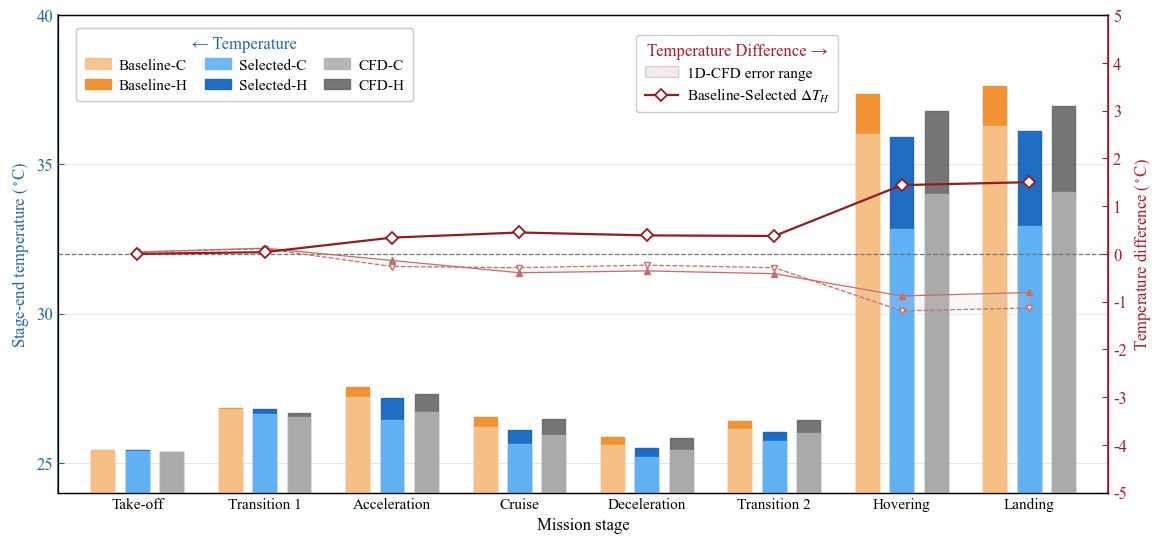


===== Baseline =====
Baseline-H: [25.413 26.833 27.524 26.529 25.868 26.392 37.345 37.636]
Baseline-C: [25.411 26.788 27.215 26.193 25.59  26.12  36.034 36.273]

===== Selected 1D =====
Selected-H: [25.411 26.798 27.183 26.081 25.48  26.017 35.905 36.134]
Selected-C: [25.404 26.638 26.443 25.639 25.188 25.719 32.822 32.945]

===== CFD =====
CFD-H: [25.37  26.678 27.321 26.476 25.837 26.432 36.786 36.943]
CFD-C: [25.367 26.53  26.707 25.929 25.424 26.007 34.016 34.078]

===== 1D - CFD prediction error =====
1D-CFD Delta-H: [ 0.041  0.12  -0.138 -0.395 -0.357 -0.415 -0.881 -0.809]
1D-CFD Delta-C: [ 0.037  0.108 -0.264 -0.29  -0.236 -0.289 -1.194 -1.134]

===== Baseline - Selected Tmax reduction =====
Baseline-Selected Delta-H: [1.000e-03 3.500e-02 3.410e-01 4.480e-01 3.870e-01 3.750e-01 1.441e+00
 1.502e+00]

Saved figure: d:\eBATS\out\C0009\C0009R01_PARK25_LC_1D_EVAL_COMBINED_COMPARE.png
Saved figure: d:\eBATS\out\C0009\C0009R01_PARK25_LC_1D_EVAL_COMBINED_COMPARE.pdf


In [15]:
# ============================================================
# Cell 8 - Baseline / Selected 1D / CFD Comparison
#
# Bars:
#   Baseline / Selected / CFD stage-end Tmax and Tmin
#
# Right axis:
#   Shaded band : 1D - CFD prediction error range
#   Line        : Baseline - Selected Tmax reduction
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ------------------------------------------------------------
# check CFD data
# ------------------------------------------------------------
if not ENABLE_CFD_COMPARISON:
    raise RuntimeError('ENABLE_CFD_COMPARISON must be True for the comparison figure.')

if 'CFD_max' not in cfd_histories or 'CFD_min' not in cfd_histories:
    raise RuntimeError('CFD_max and CFD_min must be loaded in Cell 7 before plotting.')

# ------------------------------------------------------------
# output
# ------------------------------------------------------------
os.makedirs(OUTPUT_DIR, exist_ok=True)

figure_path = os.path.join(OUTPUT_DIR, f'{RESULT_BASENAME}_COMBINED_COMPARE.png')
figure_path_pdf = os.path.join(OUTPUT_DIR, f'{RESULT_BASENAME}_COMBINED_COMPARE.pdf')

font_size = 12

# ------------------------------------------------------------
# mission stages
# ------------------------------------------------------------
stage_boundaries = np.array([6.0, 36.0, 180.0, 1560.0, 1704.0, 1734.0, 1914.0, 1920.0])
stage_labels = ['Take-off', 'Transition 1', 'Acceleration', 'Cruise', 'Deceleration', 'Transition 2', 'Hovering', 'Landing']
x = np.arange(len(stage_labels))

# ------------------------------------------------------------
# stage-end Selected temperatures
# ------------------------------------------------------------
selected_h_end = np.interp(stage_boundaries, histories['time_s'], histories['Tmax_C'])
selected_c_end = np.interp(stage_boundaries, histories['time_s'], histories['Tmin_C'])

# ------------------------------------------------------------
# stage-end Baseline temperatures
# ------------------------------------------------------------
baseline_h_end = np.interp(stage_boundaries, baseline_histories['time_s'], baseline_histories['Tmax_C'])
baseline_c_end = np.interp(stage_boundaries, baseline_histories['time_s'], baseline_histories['Tmin_C'])

# ------------------------------------------------------------
# stage-end CFD temperatures
# ------------------------------------------------------------
time_cfd_max, temperature_cfd_max = cfd_histories['CFD_max']
time_cfd_min, temperature_cfd_min = cfd_histories['CFD_min']

cfd_h_end = np.interp(stage_boundaries, time_cfd_max, temperature_cfd_max)
cfd_c_end = np.interp(stage_boundaries, time_cfd_min, temperature_cfd_min)

# ------------------------------------------------------------
# temperature differences
# ------------------------------------------------------------
delta_h_end = selected_h_end - cfd_h_end
delta_c_end = selected_c_end - cfd_c_end
delta_baseline_selected_h_end = baseline_h_end - selected_h_end

# ------------------------------------------------------------
# 1D-CFD error-band limits
# ------------------------------------------------------------
delta_error_low = np.minimum(delta_h_end, delta_c_end)
delta_error_high = np.maximum(delta_h_end, delta_c_end)

# ------------------------------------------------------------
# plot settings
# ------------------------------------------------------------
plt.rcdefaults()

plt.rcParams.update({
    'font.family': 'Times New Roman',
    'mathtext.fontset': 'stix',
    'font.size': font_size,
    'axes.labelsize': font_size,
    'axes.titlesize': font_size,
    'xtick.labelsize': font_size - 1,
    'ytick.labelsize': font_size,
    'axes.linewidth': 0.9,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'axes.unicode_minus': False
})

left_axis_color = '#2166AC'
right_axis_color = '#B2182B'

# ------------------------------------------------------------
# figure
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12.5, 6.2))
fig.subplots_adjust(left=0.08, right=0.92, bottom=0.18, top=0.95)

# ------------------------------------------------------------
# bar positions
# ------------------------------------------------------------
group_offset = 0.27
bar_w = 0.18

x_baseline = x - group_offset
x_selected = x
x_cfd = x + group_offset

# ------------------------------------------------------------
# colors
# ------------------------------------------------------------
baseline_h_color = '#F28E2B'
baseline_c_color = '#F6C28B'

selected_h_color = '#1565C0'
selected_c_color = '#64B5F6'

cfd_h_color = '#666666'
cfd_c_color = '#B0B0B0'

error_band_color = '#D8CCCC'
error_boundary_color = '#C76D6D'
improvement_color = '#971B1B'

# ------------------------------------------------------------
# Baseline temperature bars
# ------------------------------------------------------------
bars_baseline_h = ax.bar(x_baseline, baseline_h_end, width=bar_w, color=baseline_h_color, edgecolor=baseline_h_color, alpha=0.95, label='Baseline-H', zorder=3)
bars_baseline_c = ax.bar(x_baseline, baseline_c_end, width=bar_w, color=baseline_c_color, edgecolor=baseline_c_color, alpha=0.95, label='Baseline-C', zorder=4)

# ------------------------------------------------------------
# Selected temperature bars
# ------------------------------------------------------------
bars_selected_h = ax.bar(x_selected, selected_h_end, width=bar_w, color=selected_h_color, edgecolor=selected_h_color, alpha=0.95, label='Selected-H', zorder=3)
bars_selected_c = ax.bar(x_selected, selected_c_end, width=bar_w, color=selected_c_color, edgecolor=selected_c_color, alpha=0.95, label='Selected-C', zorder=4)

# ------------------------------------------------------------
# CFD temperature bars
# ------------------------------------------------------------
bars_cfd_h = ax.bar(x_cfd, cfd_h_end, width=bar_w, color=cfd_h_color, edgecolor=cfd_h_color, alpha=0.90, label='CFD-H', zorder=3)
bars_cfd_c = ax.bar(x_cfd, cfd_c_end, width=bar_w, color=cfd_c_color, edgecolor=cfd_c_color, alpha=0.90, label='CFD-C', zorder=4)

# ------------------------------------------------------------
# left axis: temperature
# ------------------------------------------------------------
ax.set_xlim(-0.62, len(stage_labels) - 0.38)
ax.set_xticks(x)
ax.set_xticklabels(stage_labels)
ax.set_xlabel('Mission stage')

ax.set_ylabel(r'Stage-end temperature ($^\circ$C)', color=left_axis_color)
ax.tick_params(axis='y', colors=left_axis_color)

ax.spines['left'].set_color(left_axis_color)
ax.spines['left'].set_linewidth(1.2)

# LC-PARK temperature range
ax.set_ylim(24.0, 40.0)
ax.set_yticks(np.arange(25.0, 40.1, 5.0))

ax.grid(axis='y', alpha=0.28, zorder=0)

# ------------------------------------------------------------
# right axis: temperature difference
# ------------------------------------------------------------
ax_r = ax.twinx()

# ------------------------------------------------------------
# 1D-CFD prediction-error band
# ------------------------------------------------------------
ax_r.fill_between(x, delta_error_low, delta_error_high, color=error_band_color, alpha=0.16, linewidth=0.0, zorder=4)

# ------------------------------------------------------------
# error-band boundaries
# ------------------------------------------------------------
line_error_h, = ax_r.plot(x, delta_h_end, color=error_boundary_color, linestyle='-', linewidth=0.9, marker='^', markersize=4.8, markerfacecolor=error_boundary_color, markeredgecolor=error_boundary_color, zorder=5)

line_error_c, = ax_r.plot(x, delta_c_end, color=error_boundary_color, linestyle='--', linewidth=0.9, marker='v', markersize=4.8, markerfacecolor='white', markeredgecolor=error_boundary_color, markeredgewidth=1.0, zorder=5)

# ------------------------------------------------------------
# Baseline - Selected Tmax reduction
# ------------------------------------------------------------
line_improvement, = ax_r.plot(x, delta_baseline_selected_h_end, color=improvement_color, linestyle='-', linewidth=1.6, marker='D', markersize=6.0, markerfacecolor='white', markeredgecolor=improvement_color, markeredgewidth=1.3, label=r'Baseline-Selected $\Delta T_H$', zorder=7)

# ------------------------------------------------------------
# zero line
# ------------------------------------------------------------
ax_r.axhline(0.0, color='0.45', linestyle='--', linewidth=0.9, zorder=1)

# ------------------------------------------------------------
# right axis style
# ------------------------------------------------------------
ax_r.set_ylabel(r'Temperature difference ($^\circ$C)', color=right_axis_color)
ax_r.tick_params(axis='y', colors=right_axis_color)

ax_r.spines['right'].set_color(right_axis_color)
ax_r.spines['right'].set_linewidth(1.2)

ax_r.set_ylim(-5.0, 5.0)
ax_r.set_yticks(np.arange(-5.0, 5.1, 1.0))

# ------------------------------------------------------------
# temperature legend
# ------------------------------------------------------------
temperature_handles = [bars_baseline_c[0], bars_baseline_h[0], bars_selected_c[0], bars_selected_h[0], bars_cfd_c[0], bars_cfd_h[0]]
temperature_labels = ['Baseline-C', 'Baseline-H', 'Selected-C', 'Selected-H', 'CFD-C', 'CFD-H']

legend_temp = ax.legend(
    temperature_handles,
    temperature_labels,
    title='← Temperature',
    loc='upper left',
    bbox_to_anchor=(0.01, 0.99),
    ncol=3,
    fontsize=font_size - 1,
    title_fontsize=font_size,
    frameon=True,
    fancybox=True,
    framealpha=1.0,
    facecolor='white',
    edgecolor='0.80',
    columnspacing=1.10,
    handlelength=1.7,
    handletextpad=0.55,
    labelspacing=0.40,
    borderpad=0.55
)

legend_temp.get_title().set_color(left_axis_color)
legend_temp.set_zorder(20)
ax.add_artist(legend_temp)

# ------------------------------------------------------------
# temperature-difference legend
# ------------------------------------------------------------
error_band_handle = Patch(facecolor=error_band_color, edgecolor=error_boundary_color, alpha=0.35)

legend_delta = ax_r.legend(
    [error_band_handle, line_improvement],
    [r'1D-CFD error range', r'Baseline-Selected $\Delta T_H$'],
    title='Temperature Difference →',
    loc='upper right',
    bbox_to_anchor=(0.75, 0.975),
    ncol=1,
    fontsize=font_size - 1,
    title_fontsize=font_size,
    frameon=True,
    fancybox=True,
    framealpha=1.0,
    facecolor='white',
    edgecolor='0.80',
    handlelength=2.2,
    handletextpad=0.55,
    labelspacing=0.45,
    borderpad=0.55
)

legend_delta.get_title().set_color(right_axis_color)
legend_delta.set_zorder(20)

# ------------------------------------------------------------
# save
# ------------------------------------------------------------
plt.savefig(figure_path, dpi=600, bbox_inches='tight')
plt.savefig(figure_path_pdf, dpi=600, bbox_inches='tight')

plt.show()

# ------------------------------------------------------------
# print values
# ------------------------------------------------------------
print()
print('===== Baseline =====')
print('Baseline-H:', np.round(baseline_h_end, 3))
print('Baseline-C:', np.round(baseline_c_end, 3))

print()
print('===== Selected 1D =====')
print('Selected-H:', np.round(selected_h_end, 3))
print('Selected-C:', np.round(selected_c_end, 3))

print()
print('===== CFD =====')
print('CFD-H:', np.round(cfd_h_end, 3))
print('CFD-C:', np.round(cfd_c_end, 3))

print()
print('===== 1D - CFD prediction error =====')
print('1D-CFD Delta-H:', np.round(delta_h_end, 3))
print('1D-CFD Delta-C:', np.round(delta_c_end, 3))

print()
print('===== Baseline - Selected Tmax reduction =====')
print('Baseline-Selected Delta-H:', np.round(delta_baseline_selected_h_end, 3))

print()
print(f'Saved figure: {figure_path}')
print(f'Saved figure: {figure_path_pdf}')